# Initial Exploration

## EDA
- Useful for initial insights into a dataset
- Process of cleaning and reviewing data to derive insights
- Informs next steps

## A first look with .head()

In [5]:
import pandas as pd
books = pd.read_csv("../datasets/clean_books.csv")
books.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens


## Using .info()
- Gives info about datatypes, memory usage, missing values

In [6]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    str    
 1   author  350 non-null    str    
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 13.8 KB


## Using value_counts
- Gives number of repeated values in a column

In [7]:
books.value_counts("genre")

genre
Non Fiction    179
Fiction        131
Childrens       40
Name: count, dtype: int64

## .describe()
- gives summary statistics for numerical columns

In [8]:
books.describe()

,rating,year
count,350.000000,350.000000
mean,4.608571,2013.508571
std,0.226941,3.284711
min,3.300000,2009.000000
25%,4.500000,2010.000000
50%,4.600000,2013.000000
75%,4.800000,2016.000000
max,4.900000,2019.000000


## Visualizing numerical data
- Using seaborn and matplotlib
- sns.histplot(data, x, binwidth) for basic histogram

In [ ]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=books, x='rating',binwidth=0.1)
plt.show()

# Data Validation

## Validating data types
- .info() can be used, or df.dtypes (<- no parens) for just the datatypes

In [12]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    str    
 1   author  350 non-null    str    
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 13.8 KB


In [13]:
books.dtypes

name          str
author        str
rating    float64
year        int64
genre         str
dtype: object

## Updating data types
- ex. the year is a float (note that the actual data here was already cleaned, so I dirty it first) 

In [14]:
books['year']=books['year'].astype(float)
books.dtypes

name          str
author        str
rating    float64
year      float64
genre         str
dtype: object

In [15]:
books['year']=books['year'].astype(int)
books.dtypes

name          str
author        str
rating    float64
year        int64
genre         str
dtype: object

In [16]:
def to_int(df, col):
    return df[col].astype(int)

books['year']= to_int(books, 'year')

### list of types and names

|type  | python name |
|------|-------------|
|string| `str`|
|integer| `int`|
|float| `float`|
|dictionary| `dict`|
|list|`list`|
|Boolean|`bool`|

## Validating categorical data
- use df['col'].isin() or df.isin()
- ~df['col'].isin() for a "is NOT in"

In [17]:
books["genre"].isin(["Fiction","Nonfiction"])

0      False
1       True
2      False
3       True
4      False
       ...  
345    False
346     True
347    False
348     True
349    False
Name: genre, Length: 350, dtype: bool

- Ex. filter the data frame to just books in the non-fiction genre

In [18]:
filt = books['genre'].isin(["Non Fiction"])
books[filt].head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,2018,Non Fiction
10,A Patriot's History of the United States: From...,Larry Schweikart,4.6,2010,Non Fiction
11,A Stolen Life: A Memoir,Jaycee Dugard,4.6,2011,Non Fiction


## Validating numerical data
- can select only numerical columns by using `df.select_dtypes("number")`
- Find max and min values using `df['col'].max()` or `df['col'].min()`
- Use `sns.boxplot(data=df, x='col')` to see distribution of values in a numerical column

   rating  year
0     4.7  2016
1     4.6  2011
2     4.7  2018
3     4.7  2017
4     4.8  2019
Minimum rating is 3.3 and maximum is 4.9


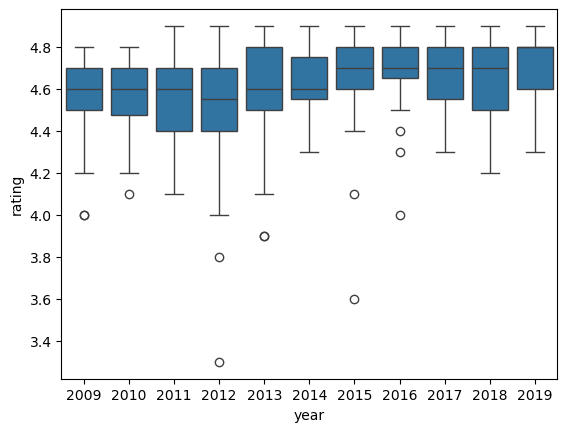

In [25]:
print(books.select_dtypes("number").head())
print(f"Minimum rating is {books['rating'].min()} and maximum is {books['rating'].max()}")
sns.boxplot(data=books,x="year",y="rating")
plt.show()

# Data Summarization

## Exploring groups of data
- Use .groupby(), then chain an aggregating function (ex. mean)

In [30]:
books[['genre','rating','year']].groupby('genre').mean()

,rating,year
genre,,
Childrens,4.780000,2015.075000
Fiction,4.570229,2013.022901
Non Fiction,4.598324,2013.513966


## Aggregating functions
|Value | Function|
|------|---------|
|Sum|`.sum()`|
|Count|`.count()`|
|Minimum|`.min()`|
|Maximum|`.max()`|
|Variance|`.var()`|
|Standard Deviation| `.std()`|

## Aggregating ungrouped data
- `.agg()` applies aggregating functions across a DataFrame
- Aggregates across all rows in a given column. Typically used when applying multiple functions
- Use a dictionary to specify aggregations for columns

In [42]:
books[["rating","year"]].agg(['mean','std'])

,rating,year
mean,4.608571,2013.508571
std,0.226941,3.284711


In [43]:
books.agg({'rating':['mean','std'],"year":["median"]})

,rating,year
mean,4.608571,NaN
std,0.226941,NaN
median,NaN,2013.0


## Named summary columns
- in the argument for df.agg(), give a list of `summary_column = ('col_name','aggfunc')`

In [45]:
books.groupby("genre").agg(
    mean_rating=("rating", "mean"),
    std_rating=("rating","std"),
    median_year=("year","median")
)

,mean_rating,std_rating,median_year
genre,,,
Childrens,4.780000,0.122370,2015.0
Fiction,4.570229,0.281123,2013.0
Non Fiction,4.598324,0.179411,2013.0


## Visualizing categorical summaries
- Barplots automatically calculate mean of a quantitative variable and show 95% confidence interval

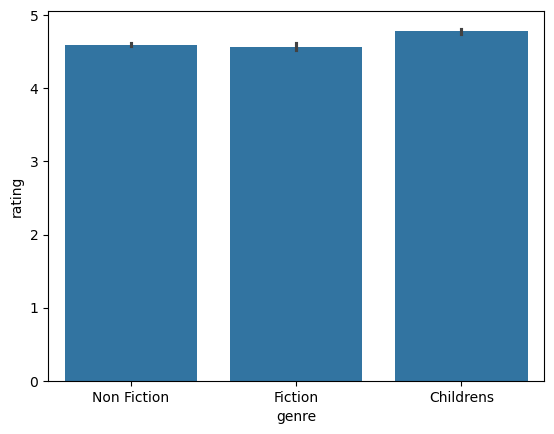

In [46]:
sns.barplot(data=books, x='genre', y='rating')
plt.show()